In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions

In [5]:
class Perceptron(object):

    def __init__(self, eta=0.01, epochs=50):
        self.eta = eta
        self.epochs = epochs

    def train(self, x, y):
        ## Jedes Merkmal enthält 2 Gewichte, eines für die Klasse 0 und eines für die Klasse 1
        self.w = np.zeros(x.shape[1])
        self.b = 0
        self.errors = []
        for n in range(self.epochs):
            fehler = 0
            for xi, target in zip(x, y):
                yhat = self.predict(xi)
                update = self.eta * (target - yhat)
                if update != 0.0:
                    self.w += update * xi
                    self.b += update
                    fehler += 1
            self.errors.append(fehler)
        return self
    
    def activation(self, z):
        #kjlkj
        return np.where(z >= 0.0, 1, 0)
    
    def predict(self, x):
        z = np.dot(x, self.w) + self.b
        return self.activation(z)
    

In [6]:
#Load the Iris dataset into a dataframe
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data', header=None)

In [7]:
# Choose experimental data from the dataset
## Virginica aussortieren
df = df[df.iloc[:, 4]!= 'Iris-virginica']

## Spalten 2 und 3 (Blütenblattlänge und -breite) in ein Array x speichern
x = df.iloc[:, [2, 3]].values

## Spalte 4 mit den Klassenbezeichnungen in ein Array y speichern und Iris-setosa mit 0 und Iris-versicolor mit 1 kodieren
y = df.iloc[:, 4].values
y = np.where(y == 'Iris-setosa', 0, 1)

## Damit die Länge nicht überwiegt, müssen die Werte in x normalisiert werden
## Die Werte werden so normalisiert, dass der Mittelwert 0 und die Standardabweichung 1 beträgt
x_norm = (x - x.mean(axis=0)) / x.std(axis=0)


[0.01318251 0.01419826] 0.0 [2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Genauigkeit: 100.0%


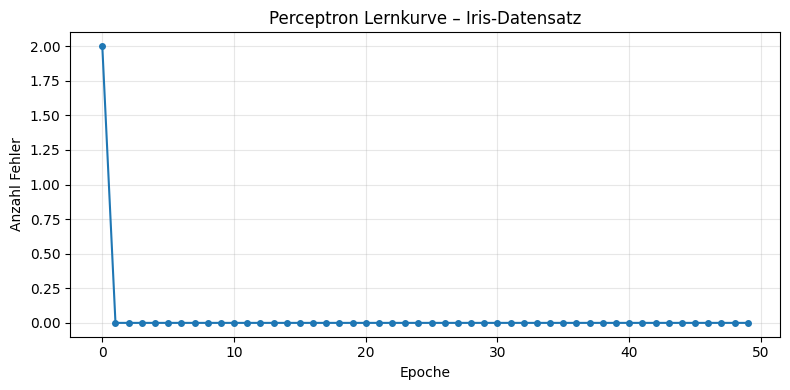

In [15]:
#Visualize results
perceptron = Perceptron().train(x_norm, y)
print(perceptron.w, perceptron.b, perceptron.errors)

richtig = sum(perceptron.predict(xi) == yi 
              for xi, yi in zip(x_norm, y))
print(f"Genauigkeit: {richtig/len(y)*100:.1f}%")

plt.figure(figsize=(8, 4))
plt.plot(perceptron.errors, marker='o', markersize=4, linewidth=1.5)
plt.xlabel("Epoche")
plt.ylabel("Anzahl Fehler")
plt.title("Perceptron Lernkurve – Iris-Datensatz")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
